<a href="https://colab.research.google.com/github/SamrudhPS/datacenter_pred/blob/main/datacenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110

df = pd.read_excel('AI_Edge_Performance_Dataset.xlsx')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Friendly short column aliases used throughout
rename_map = {
    'Ambient_Temperature_C':               'ambient_C',
    'CPU1_Temperature_C':                  'cpu1_C',
    'CPU2_Temperature_C':                  'cpu2_C',
    'Oil_Flow_L_Min':                      'oil_flow',
    'Fan_Speed_Pct':                       'fan_pct',
    'Exchanger_Air_Temp_In_C':             'air_temp_in',
    'Exchanger_Air_Temp_Out_C':            'air_temp_out',
    'Exchanger_Oil_Temp_In_C':             'oil_temp_in',
    'Exchanger_Oil_Temp_Out_C':            'oil_temp_out',
    'Oil_Power_Rejected_W':                'power_rejected_W',
    'HX_Effectiveness':                    'hx_eff',
    'Fan_Power_Consumption_W':             'fan_power_W',
    'Pump_Power_Consumption_W':            'pump_power_W',
    'Edge_Device_Power_Consumption_W':     'edge_power_W',
    'Oil_Delta_Temperature_C':             'oil_delta_C',
    'Oil_Average_Temperature_C':           'oil_avg_C',
    'Oil_Mass_Flow_g_s':                   'oil_mass_gs',
    'Oil_Density_Kg_L':                    'oil_density',
    'Oil_Specific_Heat_Cp_J_gK':           'oil_cp',
    'Air_Delta_Temperature_C':             'air_delta_C',
    'Liquid_Delta_Temperature_C':          'liq_delta_C',
    'Liquid_Max_DeltaT_Liquid_Air_Inlet_C':'liq_max_dT',
    'Air_Temperature_In_C':                'air_in_C',
    'Air_Temperature_Out_C':               'air_out_C',
    'Liquid_Temperature_In_C':             'liq_in_C',
    'Liquid_Temperature_Out_C':            'liq_out_C',
}
df.rename(columns=rename_map, inplace=True)
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 213 rows × 33 columns


,Row_Hash_ID,Timestamp,File_ID,Date,Time,Test_ID,ambient_C,CPU_State,oil_flow,fan_pct,...,air_out_C,air_delta_C,liq_in_C,liq_out_C,liq_delta_C,liq_max_dT,hx_eff,pump_power_W,fan_power_W,edge_power_W
0,6ADA842F988222ED,2025-12-04 12:30:00,441856719,2025-12-04,12:30:00,NaN,30,stress test,5.0,90,...,32.6,1.3,32.6,31.1,1.5,1.3,1.153846,12,300,312
1,5F024DFF2C80A015,2025-12-04 12:55:00,441856719,2025-12-04,12:55:00,NaN,30,stress test,5.0,90,...,35.4,2.7,38.8,33.1,5.7,6.1,0.934426,12,300,312
2,38AD149395D27EE7,2025-12-04 13:00:00,441856719,2025-12-04,13:00:00,NaN,30,stress test,5.0,90,...,35.6,2.7,39.0,33.1,5.9,6.1,0.967213,12,300,312


In [2]:
print('=== Shape ===')
print(f'  {df.shape[0]} rows  x  {df.shape[1]} columns')

print('\n=== Missing values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  None — dataset is complete ✓')

print('\n=== Duplicate rows ===')
print(f'  {df.duplicated().sum()} duplicates')

print('\n=== Records per ambient temp ===')
print(df['ambient_C'].value_counts().sort_index().to_string())

print('\n=== Records per Oil Flow ===')
print(df['oil_flow'].value_counts().sort_index().to_string())

print('\n=== Records per Fan Speed ===')
print(df['fan_pct'].value_counts().sort_index().to_string())

=== Shape ===
  213 rows  x  33 columns

=== Missing values ===
Test_ID    213
dtype: int64

=== Duplicate rows ===
  0 duplicates

=== Records per ambient temp ===
ambient_C
30    98
47    56
50    59

=== Records per Oil Flow ===
oil_flow
5.0     59
7.5     77
10.0    77

=== Records per Fan Speed ===
fan_pct
30    25
50    65
70    61
90    62


In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Numeric columns : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)} → {cat_cols}')

Numeric columns : 28
Categorical cols: 4 → ['Row_Hash_ID', 'Date', 'Time', 'CPU_State']


In [4]:
key = ['ambient_C','oil_flow','fan_pct',
       'cpu1_C','cpu2_C',
       'oil_temp_in','oil_temp_out',
       'air_temp_in','air_temp_out',
       'power_rejected_W','hx_eff',
       'fan_power_W','edge_power_W','pump_power_W']

df[key].describe().round(2)

,ambient_C,oil_flow,fan_pct,cpu1_C,cpu2_C,oil_temp_in,oil_temp_out,air_temp_in,air_temp_out,power_rejected_W,hx_eff,fan_power_W,edge_power_W,pump_power_W
count,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00
mean,40.01,7.71,65.02,76.91,81.24,48.10,44.68,42.96,45.87,684.38,0.66,159.55,188.91,29.35
std,9.33,1.99,20.09,12.42,13.14,9.13,9.56,9.38,9.25,185.39,0.16,99.70,99.25,14.85
min,30.00,5.00,30.00,39.50,42.50,32.60,31.10,31.30,32.60,126.57,0.37,30.00,54.00,12.00
25%,30.00,5.00,50.00,69.80,73.40,38.70,34.40,32.90,36.00,615.98,0.53,75.00,99.00,12.00
50%,47.00,7.50,70.00,71.40,75.10,53.30,50.90,49.80,51.80,717.24,0.63,160.00,172.00,24.00
75%,50.00,10.00,90.00,88.60,94.20,56.60,53.60,52.30,54.40,780.52,0.77,300.00,312.00,48.00
max,50.00,10.00,90.00,92.40,95.00,59.90,55.80,54.00,56.70,1175.96,1.15,300.00,348.00,48.00


In [5]:
# Group by oil flow and fan speed — mean of key metrics
df.groupby(['oil_flow','fan_pct'])[['cpu1_C','power_rejected_W','hx_eff',
                                    'oil_temp_in','air_temp_out','fan_power_W']].mean().round(2)

cpu1_C  power_rejected_W  hx_eff  oil_temp_in  air_temp_out  \
oil_flow fan_pct                                                                
5.0      50        79.26            700.25    0.79        50.06         47.02   
         70        77.40            770.11    0.85        47.24         43.78   
         90        78.65            650.38    0.84        49.22         46.37   
7.5      30        68.35            667.35    0.49        39.31         37.02   
         50        78.08            627.61    0.61        49.04         47.12   
         70        77.63            660.98    0.66        48.29         46.21   
         90        77.29            677.06    0.70        49.30         47.20   
10.0     30        73.55            633.63    0.41        44.11         42.34   
         50        77.86            639.03    0.50        49.15         47.48   
         70        76.88            679.54    0.55        49.63         47.89   
         90        75.67            813.36    0.69        48.07         46.38   

                  fan_power_W  
oil_flow fan_pct               
5.0      50              75.0  
         70             160.0  
         90             300.0  
7.5      30              30.0  
         50              75.0  
         70             160.0  
         90             300.0  
10.0     30              30.0  
         50              75.0  
         70             160.0  
         90             300.0

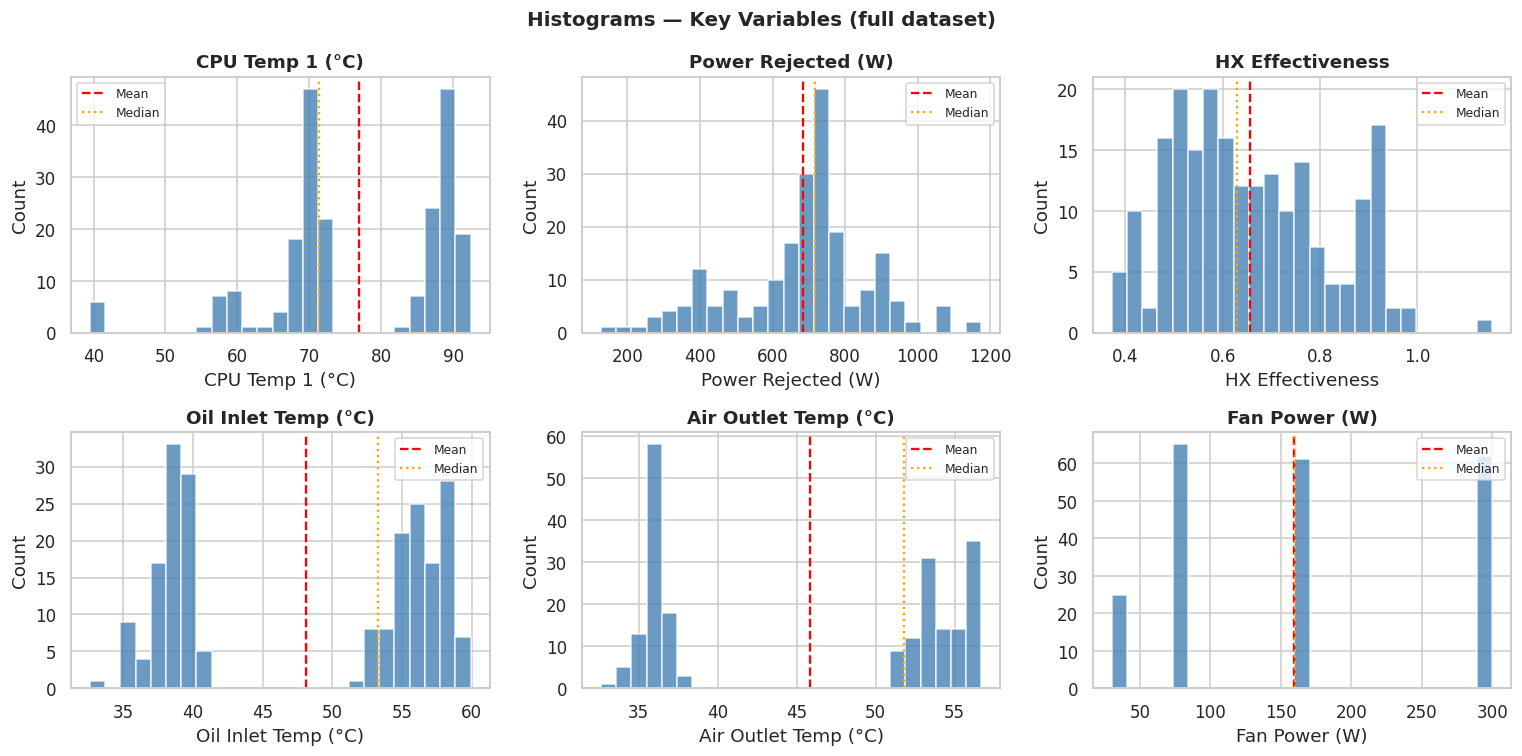

In [6]:
plot_cols = [
    ('cpu1_C',          'CPU Temp 1 (°C)'),
    ('power_rejected_W','Power Rejected (W)'),
    ('hx_eff',          'HX Effectiveness'),
    ('oil_temp_in',     'Oil Inlet Temp (°C)'),
    ('air_temp_out',    'Air Outlet Temp (°C)'),
    ('fan_power_W',     'Fan Power (W)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Histograms — Key Variables (full dataset)', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes.flat, plot_cols):
    ax.hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', lw=1.5, linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color='orange', lw=1.5, linestyle=':', label='Median')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

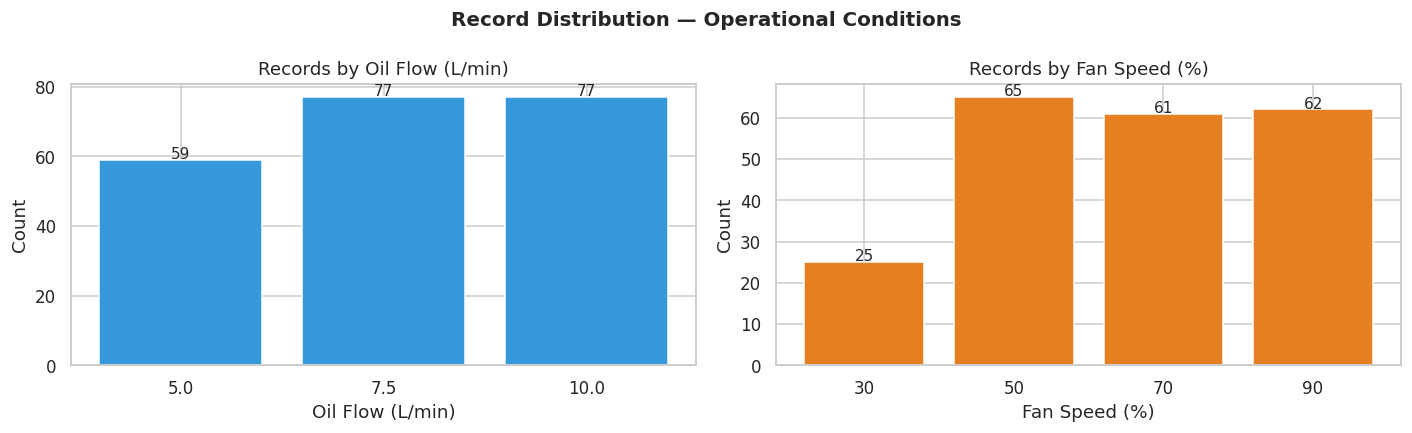

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Record Distribution — Operational Conditions', fontsize=13, fontweight='bold')

# Oil flow bar chart
oil_counts = df['oil_flow'].value_counts().sort_index()
axes[0].bar([str(x) for x in oil_counts.index], oil_counts.values,
            color='#3498db', edgecolor='white')
axes[0].set_title('Records by Oil Flow (L/min)')
axes[0].set_xlabel('Oil Flow (L/min)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2, p.get_height()+0.3,
                 str(int(p.get_height())), ha='center', fontsize=10)

# Fan speed bar chart
fan_counts = df['fan_pct'].value_counts().sort_index()
axes[1].bar([str(x) for x in fan_counts.index], fan_counts.values,
            color='#e67e22', edgecolor='white')
axes[1].set_title('Records by Fan Speed (%)')
axes[1].set_xlabel('Fan Speed (%)')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+0.3,
                 str(int(p.get_height())), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

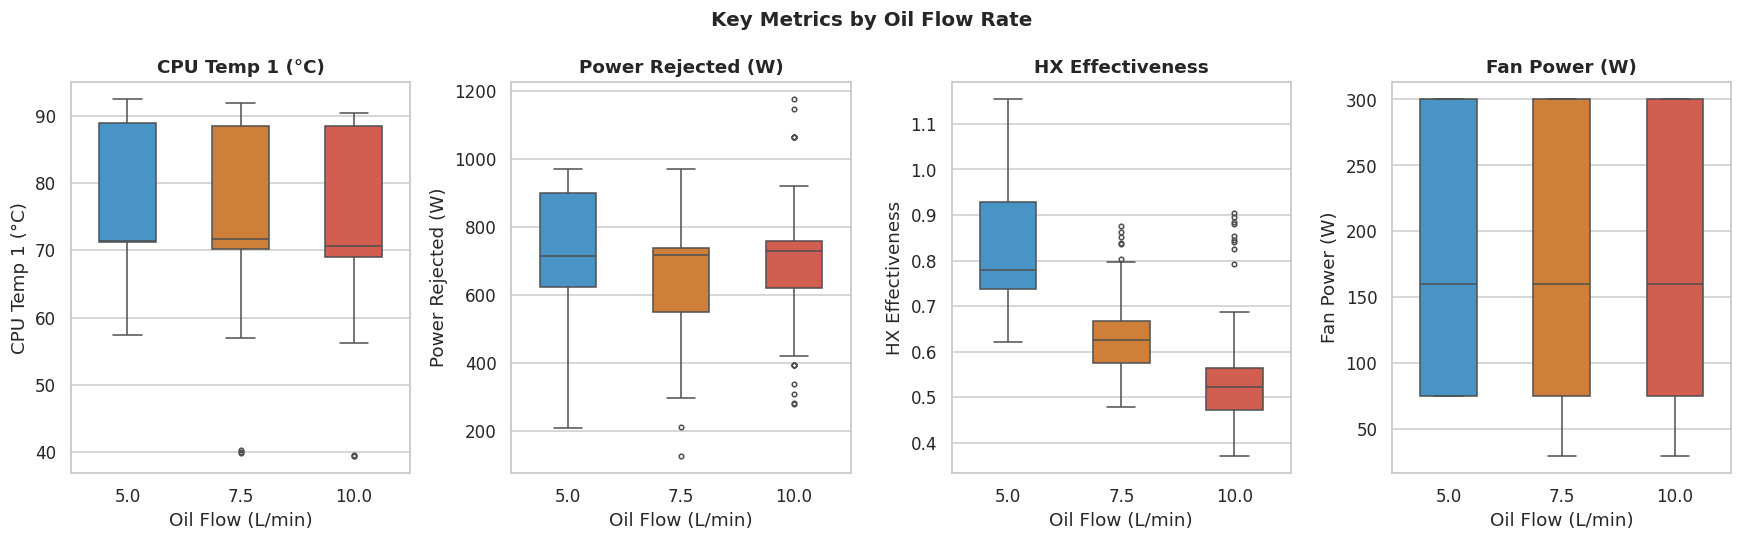

In [8]:
compare = [
    ('cpu1_C',          'CPU Temp 1 (°C)'),
    ('power_rejected_W','Power Rejected (W)'),
    ('hx_eff',          'HX Effectiveness'),
    ('fan_power_W',     'Fan Power (W)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Key Metrics by Oil Flow Rate', fontsize=13, fontweight='bold')

palette_flow = {5.0:'#3498db', 7.5:'#e67e22', 10.0:'#e74c3c'}
for ax, (col, label) in zip(axes, compare):
    sns.boxplot(data=df, x='oil_flow', y=col,
                palette=['#3498db','#e67e22','#e74c3c'], ax=ax,
                width=0.5, fliersize=3)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Oil Flow (L/min)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

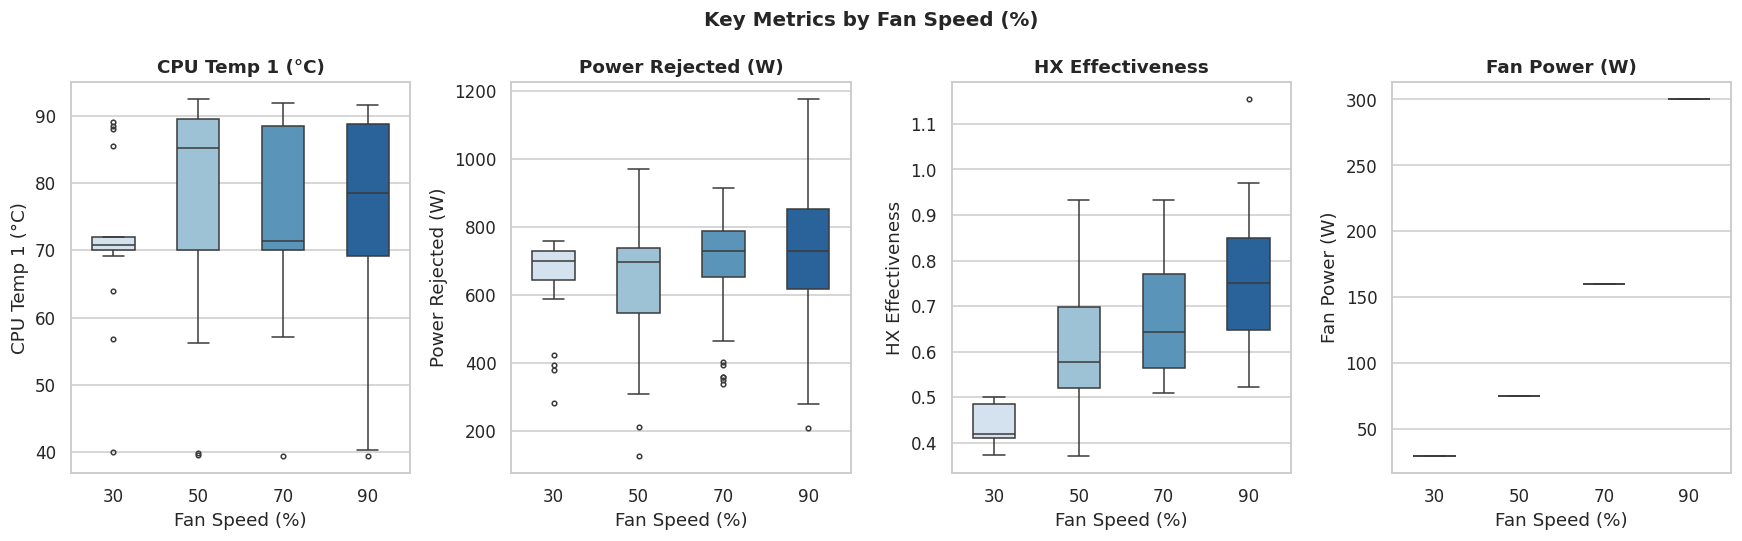

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Key Metrics by Fan Speed (%)', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, compare):
    sns.boxplot(data=df, x='fan_pct', y=col,
                palette='Blues', ax=ax, width=0.5, fliersize=3)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Fan Speed (%)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

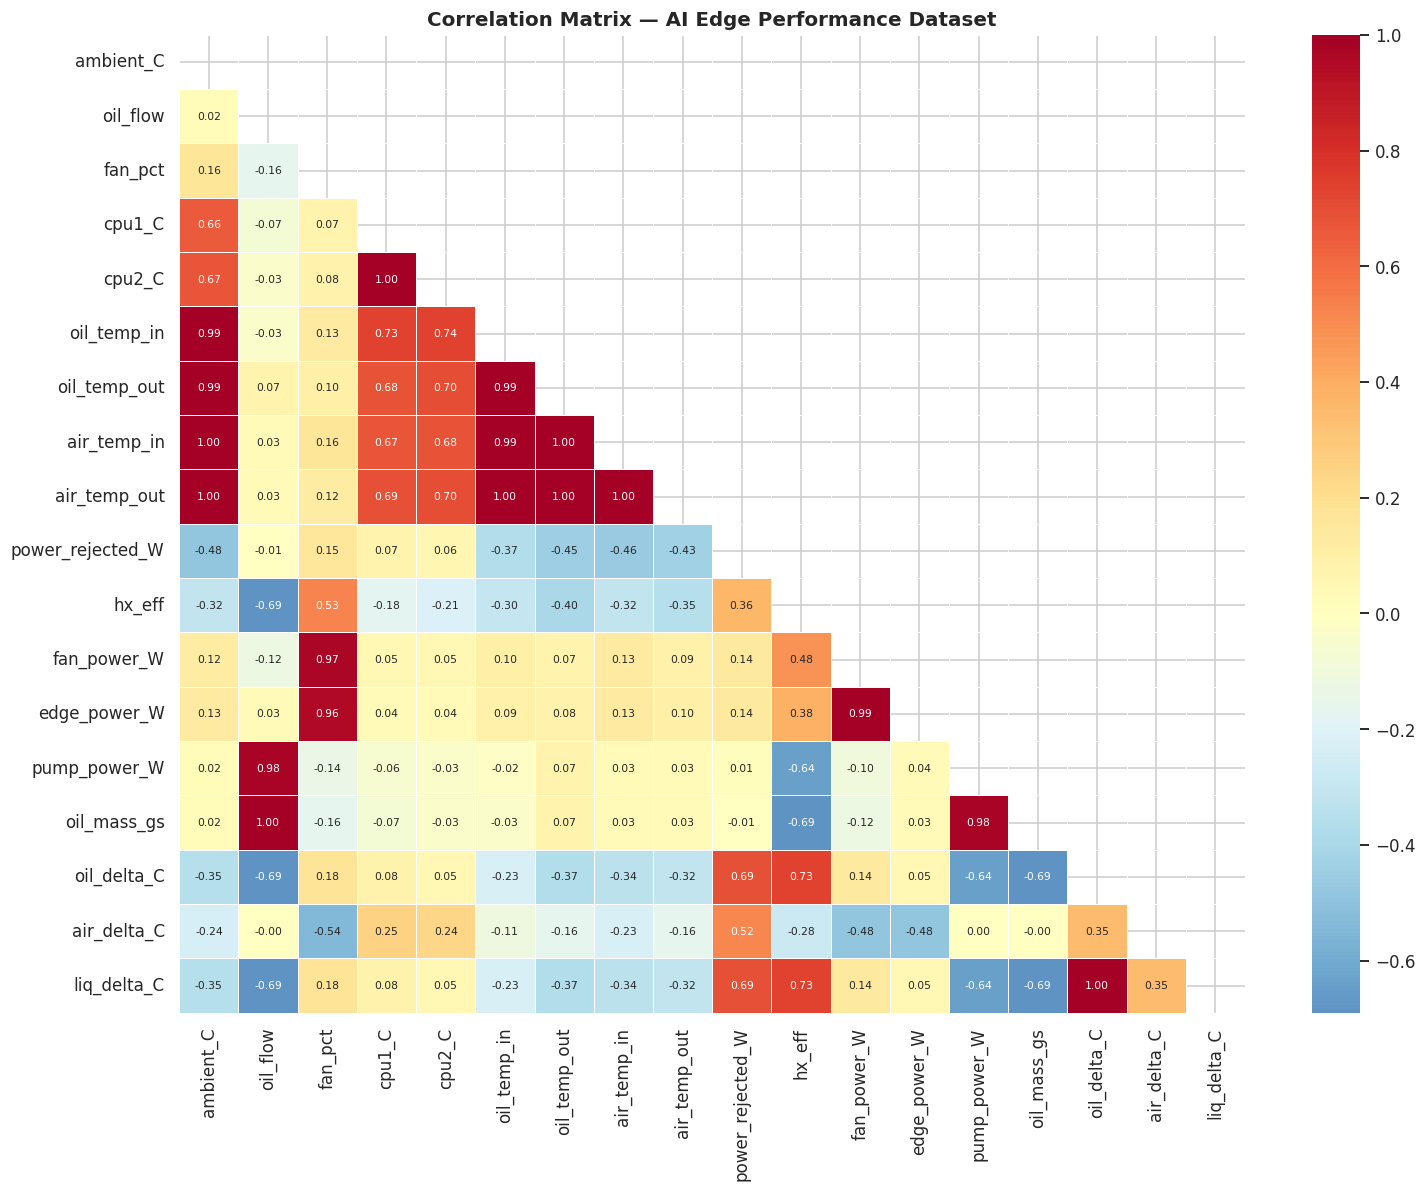

In [10]:
corr_cols = ['ambient_C','oil_flow','fan_pct',
             'cpu1_C','cpu2_C',
             'oil_temp_in','oil_temp_out',
             'air_temp_in','air_temp_out',
             'power_rejected_W','hx_eff',
             'fan_power_W','edge_power_W','pump_power_W',
             'oil_mass_gs','oil_delta_C','air_delta_C','liq_delta_C']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix — AI Edge Performance Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

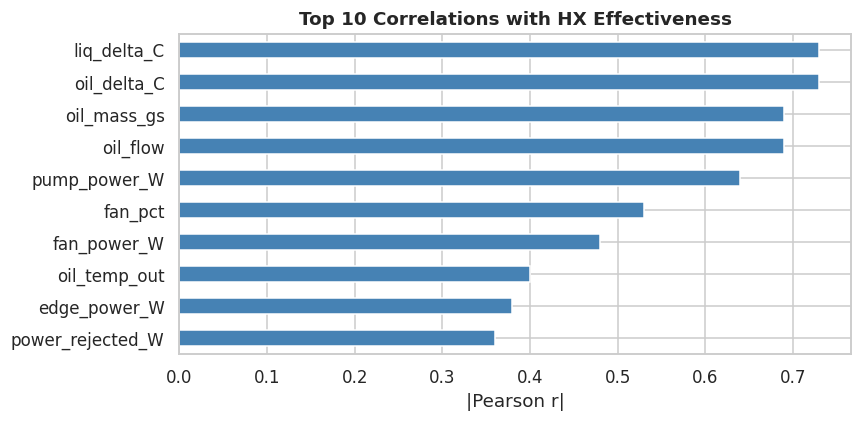

In [11]:
# Top correlations with HX Effectiveness
top_hx = corr['hx_eff'].drop('hx_eff').abs().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 4))
top_hx.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_xlabel('|Pearson r|')
ax.set_title('Top 10 Correlations with HX Effectiveness', fontweight='bold')
plt.tight_layout()
plt.show()

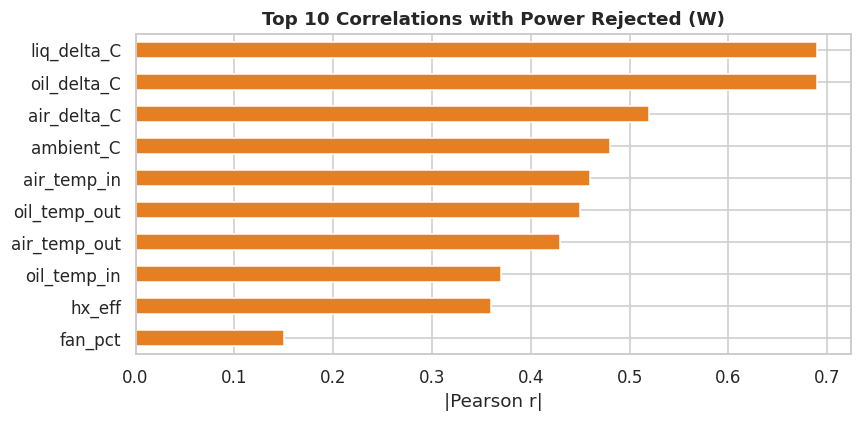

In [12]:
# Top correlations with Power Rejected
top_pwr = corr['power_rejected_W'].drop('power_rejected_W').abs().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 4))
top_pwr.plot(kind='barh', color='#e67e22', edgecolor='white', ax=ax)
ax.set_xlabel('|Pearson r|')
ax.set_title('Top 10 Correlations with Power Rejected (W)', fontweight='bold')
plt.tight_layout()
plt.show()

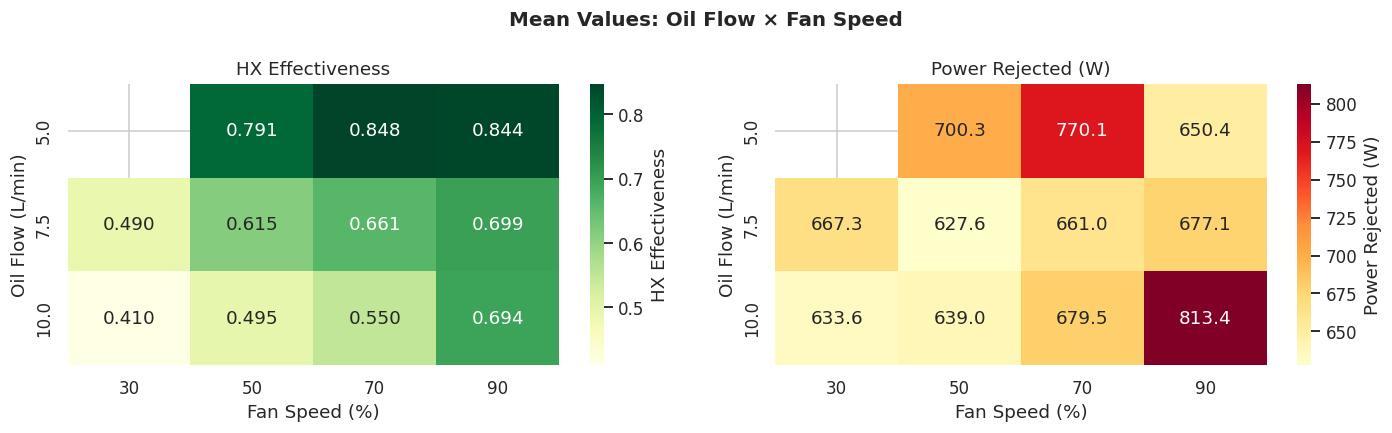

In [13]:
pivot_eff = df.groupby(['oil_flow','fan_pct'])['hx_eff'].mean().unstack().round(3)
pivot_pwr = df.groupby(['oil_flow','fan_pct'])['power_rejected_W'].mean().unstack().round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Mean Values: Oil Flow × Fan Speed', fontsize=13, fontweight='bold')

sns.heatmap(pivot_eff, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0],
            cbar_kws={'label': 'HX Effectiveness'})
axes[0].set_title('HX Effectiveness')
axes[0].set_xlabel('Fan Speed (%)')
axes[0].set_ylabel('Oil Flow (L/min)')

sns.heatmap(pivot_pwr, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Power Rejected (W)'})
axes[1].set_title('Power Rejected (W)')
axes[1].set_xlabel('Fan Speed (%)')
axes[1].set_ylabel('Oil Flow (L/min)')

plt.tight_layout()
plt.show()

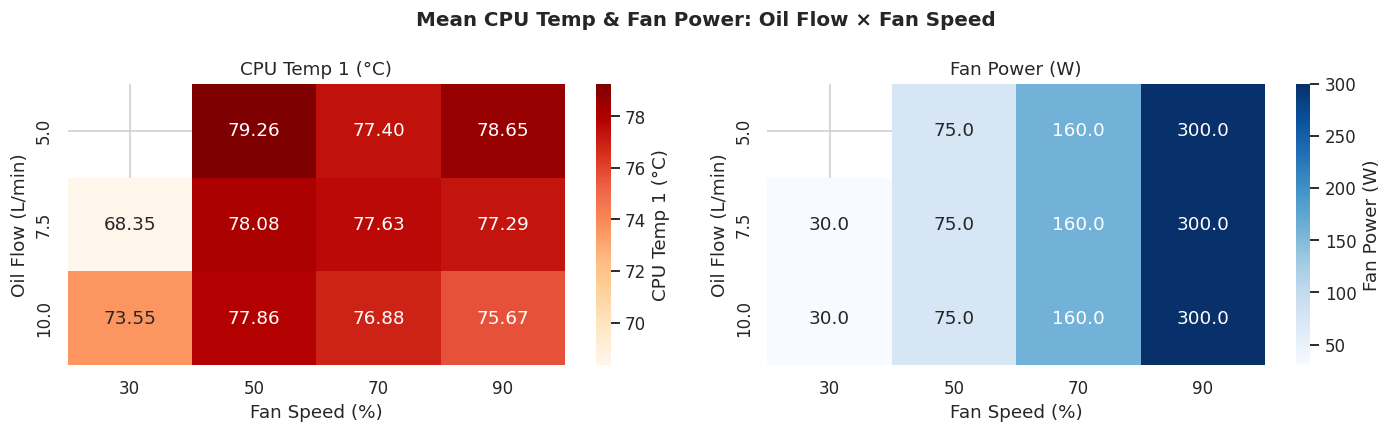

In [14]:
# Additional pivot: CPU1 Temp and Fan Power
pivot_cpu = df.groupby(['oil_flow','fan_pct'])['cpu1_C'].mean().unstack().round(2)
pivot_fan = df.groupby(['oil_flow','fan_pct'])['fan_power_W'].mean().unstack().round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Mean CPU Temp & Fan Power: Oil Flow × Fan Speed', fontsize=13, fontweight='bold')

sns.heatmap(pivot_cpu, annot=True, fmt='.2f', cmap='OrRd', ax=axes[0],
            cbar_kws={'label': 'CPU Temp 1 (°C)'})
axes[0].set_title('CPU Temp 1 (°C)')
axes[0].set_xlabel('Fan Speed (%)')
axes[0].set_ylabel('Oil Flow (L/min)')

sns.heatmap(pivot_fan, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Fan Power (W)'})
axes[1].set_title('Fan Power (W)')
axes[1].set_xlabel('Fan Speed (%)')
axes[1].set_ylabel('Oil Flow (L/min)')

plt.tight_layout()
plt.show()

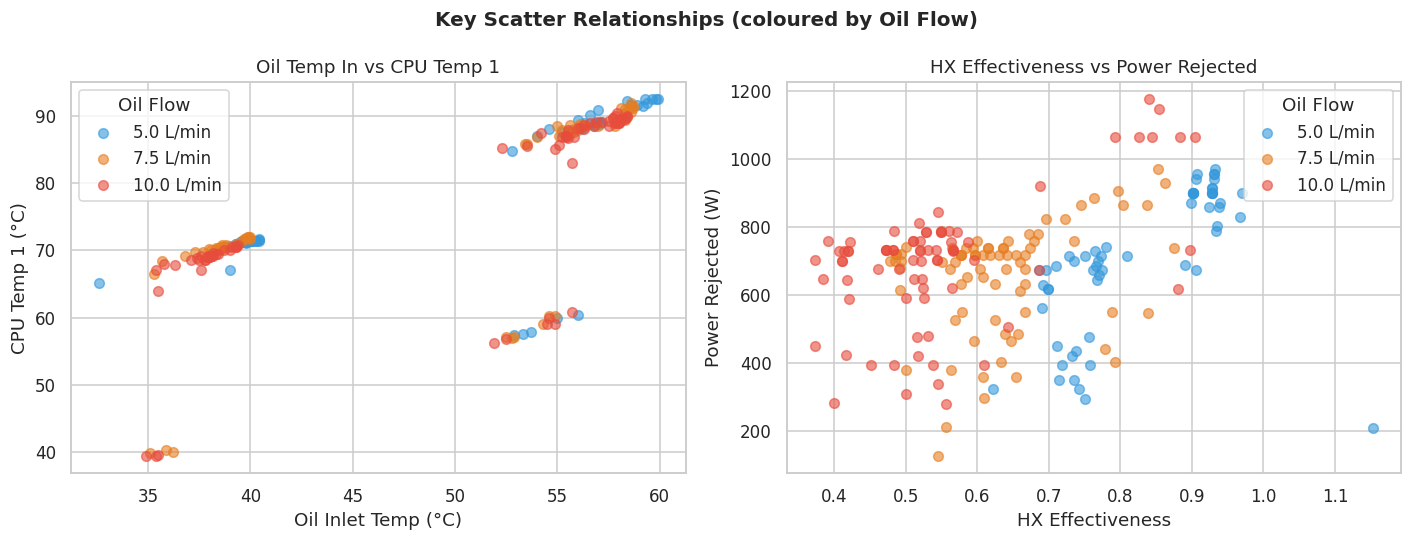

In [15]:
palette_flow = {5.0:'#3498db', 7.5:'#e67e22', 10.0:'#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Key Scatter Relationships (coloured by Oil Flow)', fontsize=13, fontweight='bold')

for flow, color in palette_flow.items():
    sub = df[df.oil_flow == flow]
    axes[0].scatter(sub['oil_temp_in'], sub['cpu1_C'],
                    color=color, alpha=0.6, s=40, label=f'{flow} L/min')
axes[0].set_xlabel('Oil Inlet Temp (°C)')
axes[0].set_ylabel('CPU Temp 1 (°C)')
axes[0].set_title('Oil Temp In vs CPU Temp 1')
axes[0].legend(title='Oil Flow')

for flow, color in palette_flow.items():
    sub = df[df.oil_flow == flow]
    axes[1].scatter(sub['hx_eff'], sub['power_rejected_W'],
                    color=color, alpha=0.6, s=40, label=f'{flow} L/min')
axes[1].set_xlabel('HX Effectiveness')
axes[1].set_ylabel('Power Rejected (W)')
axes[1].set_title('HX Effectiveness vs Power Rejected')
axes[1].legend(title='Oil Flow')

plt.tight_layout()
plt.show()

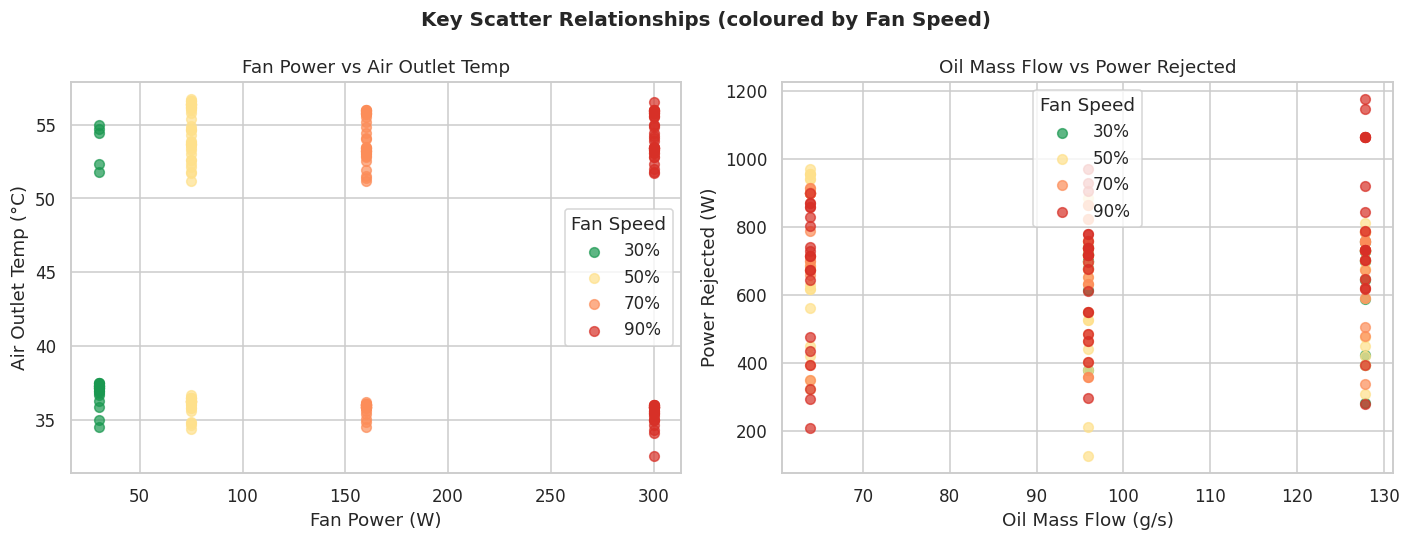

In [16]:
# Fan speed vs metrics scatter
palette_fan = {30:'#1a9850', 50:'#fee08b', 70:'#fc8d59', 90:'#d73027'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Key Scatter Relationships (coloured by Fan Speed)', fontsize=13, fontweight='bold')

for fan, color in palette_fan.items():
    sub = df[df.fan_pct == fan]
    axes[0].scatter(sub['fan_power_W'], sub['air_temp_out'],
                    color=color, alpha=0.7, s=40, label=f'{fan}%')
axes[0].set_xlabel('Fan Power (W)')
axes[0].set_ylabel('Air Outlet Temp (°C)')
axes[0].set_title('Fan Power vs Air Outlet Temp')
axes[0].legend(title='Fan Speed')

for fan, color in palette_fan.items():
    sub = df[df.fan_pct == fan]
    axes[1].scatter(sub['oil_mass_gs'], sub['power_rejected_W'],
                    color=color, alpha=0.7, s=40, label=f'{fan}%')
axes[1].set_xlabel('Oil Mass Flow (g/s)')
axes[1].set_ylabel('Power Rejected (W)')
axes[1].set_title('Oil Mass Flow vs Power Rejected')
axes[1].legend(title='Fan Speed')

plt.tight_layout()
plt.show()

In [17]:
palette_flow_ts = {5.0: '#3498db', 7.5: '#e67e22', 10.0: '#e74c3c'}

def ts_by_flow(col, ylabel, title, palette=palette_flow_ts):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, flow in zip(axes, [5.0, 7.5, 10.0]):
        sub = df[df.oil_flow == flow].copy()
        color = palette[flow]
        ax.plot(sub.Timestamp, sub[col], color=color, lw=1.2, alpha=0.9)
        ax.set_ylabel(ylabel)
        ax.set_title(f'Oil Flow = {flow} L/min', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

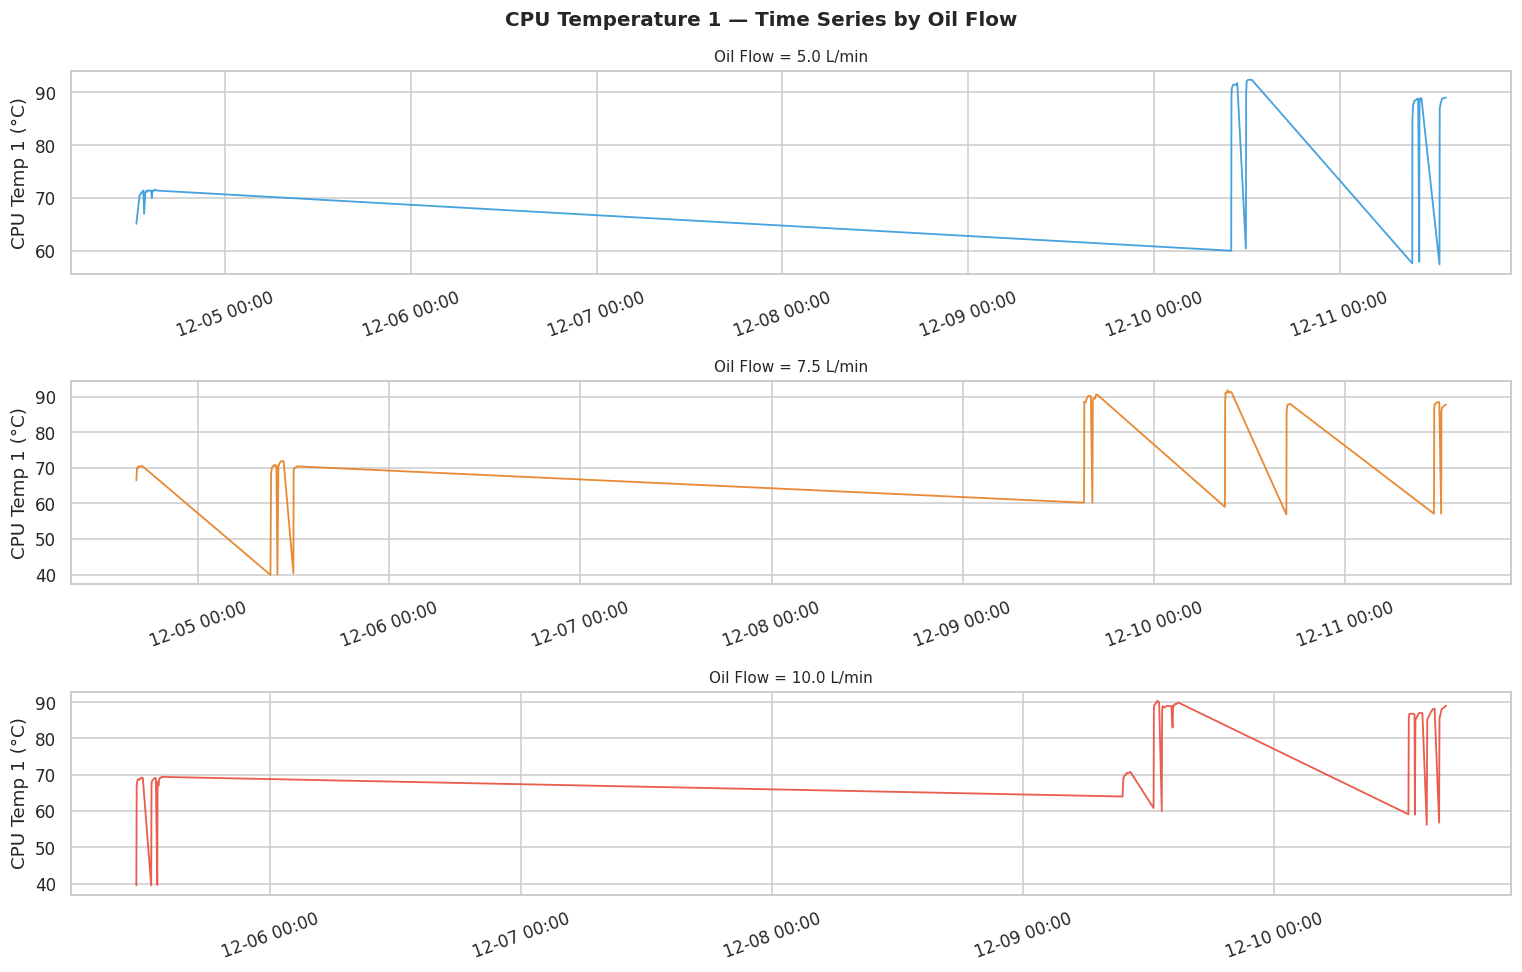

In [18]:
ts_by_flow('cpu1_C', 'CPU Temp 1 (°C)',
           'CPU Temperature 1 — Time Series by Oil Flow')

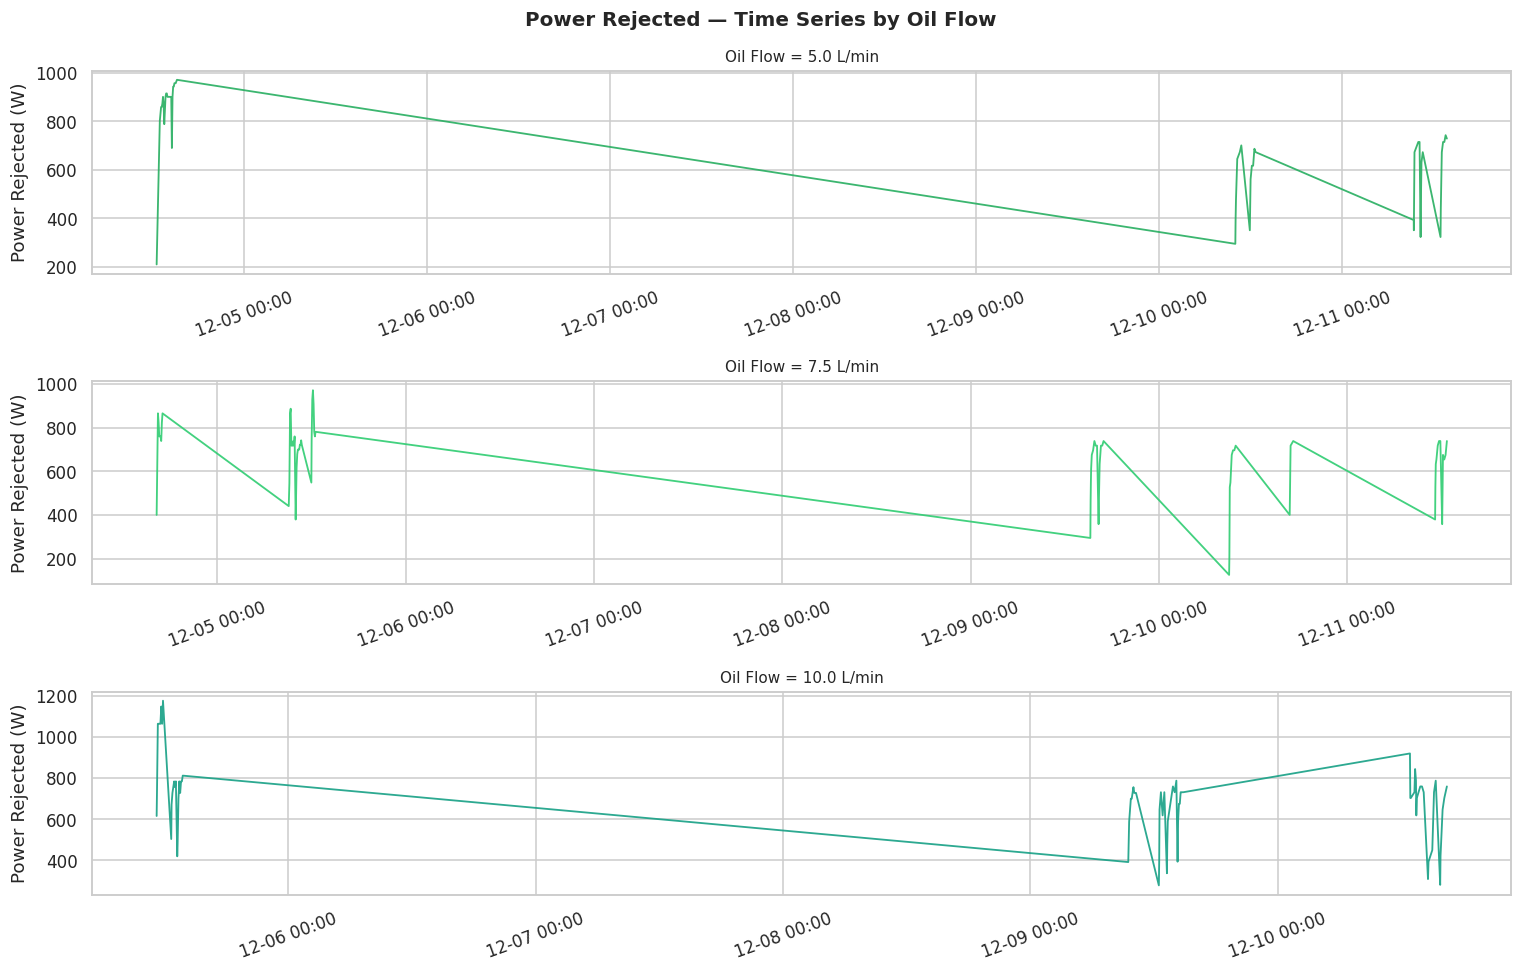

In [19]:
ts_by_flow('power_rejected_W', 'Power Rejected (W)',
           'Power Rejected — Time Series by Oil Flow',
           palette={5.0:'#27ae60', 7.5:'#2ecc71', 10.0:'#16a085'})

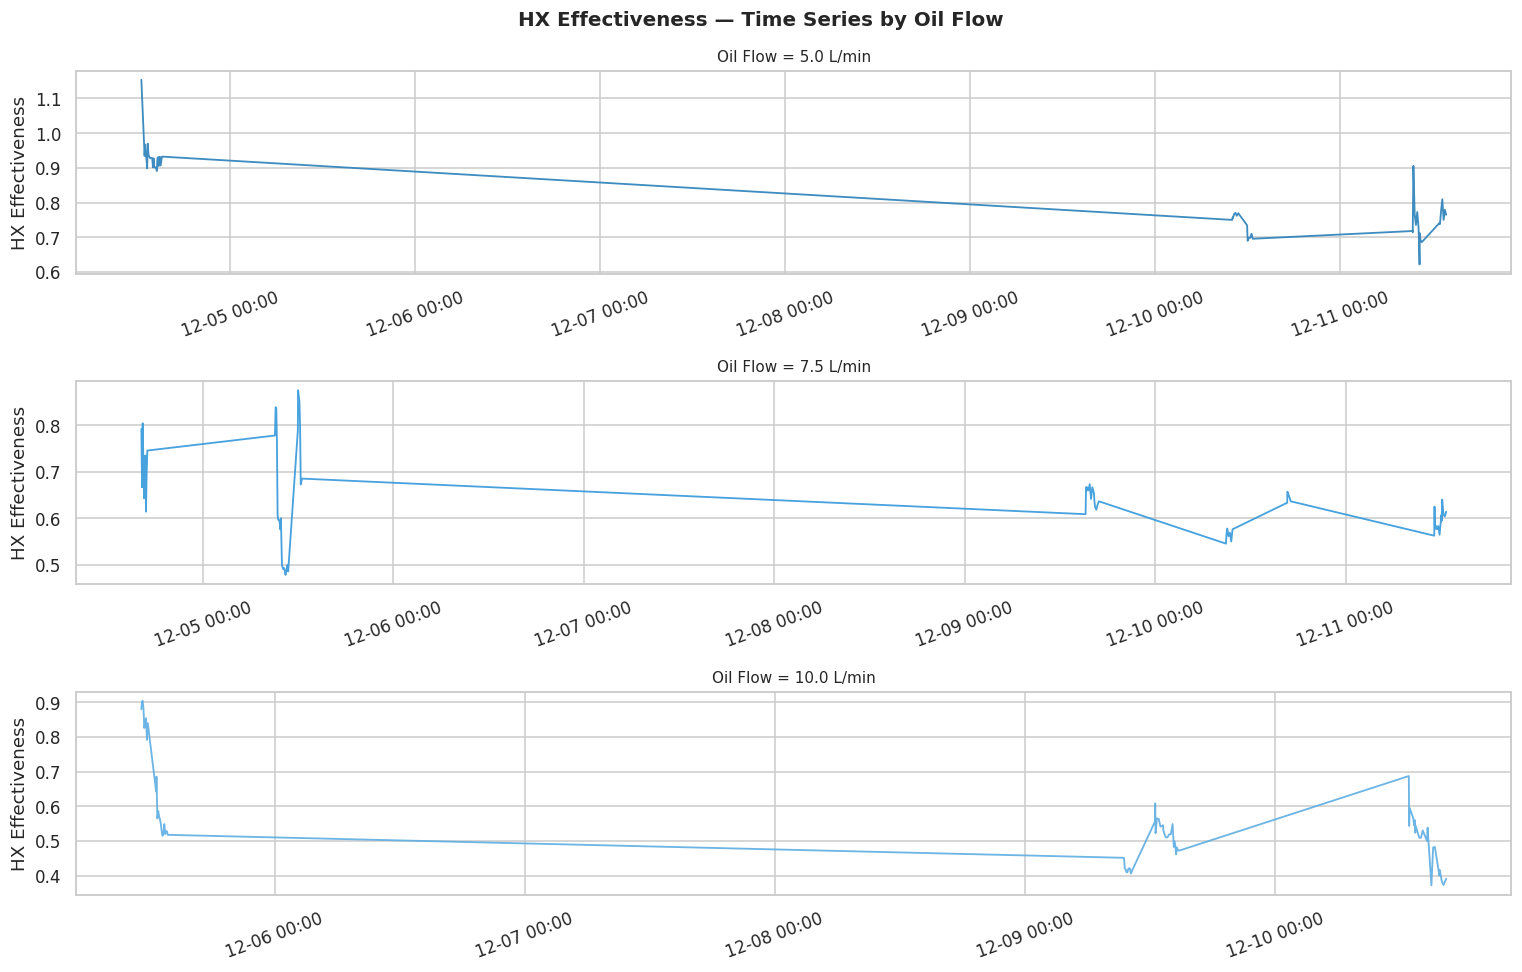

In [20]:
ts_by_flow('hx_eff', 'HX Effectiveness',
           'HX Effectiveness — Time Series by Oil Flow',
           palette={5.0:'#2980b9', 7.5:'#3498db', 10.0:'#5dade2'})

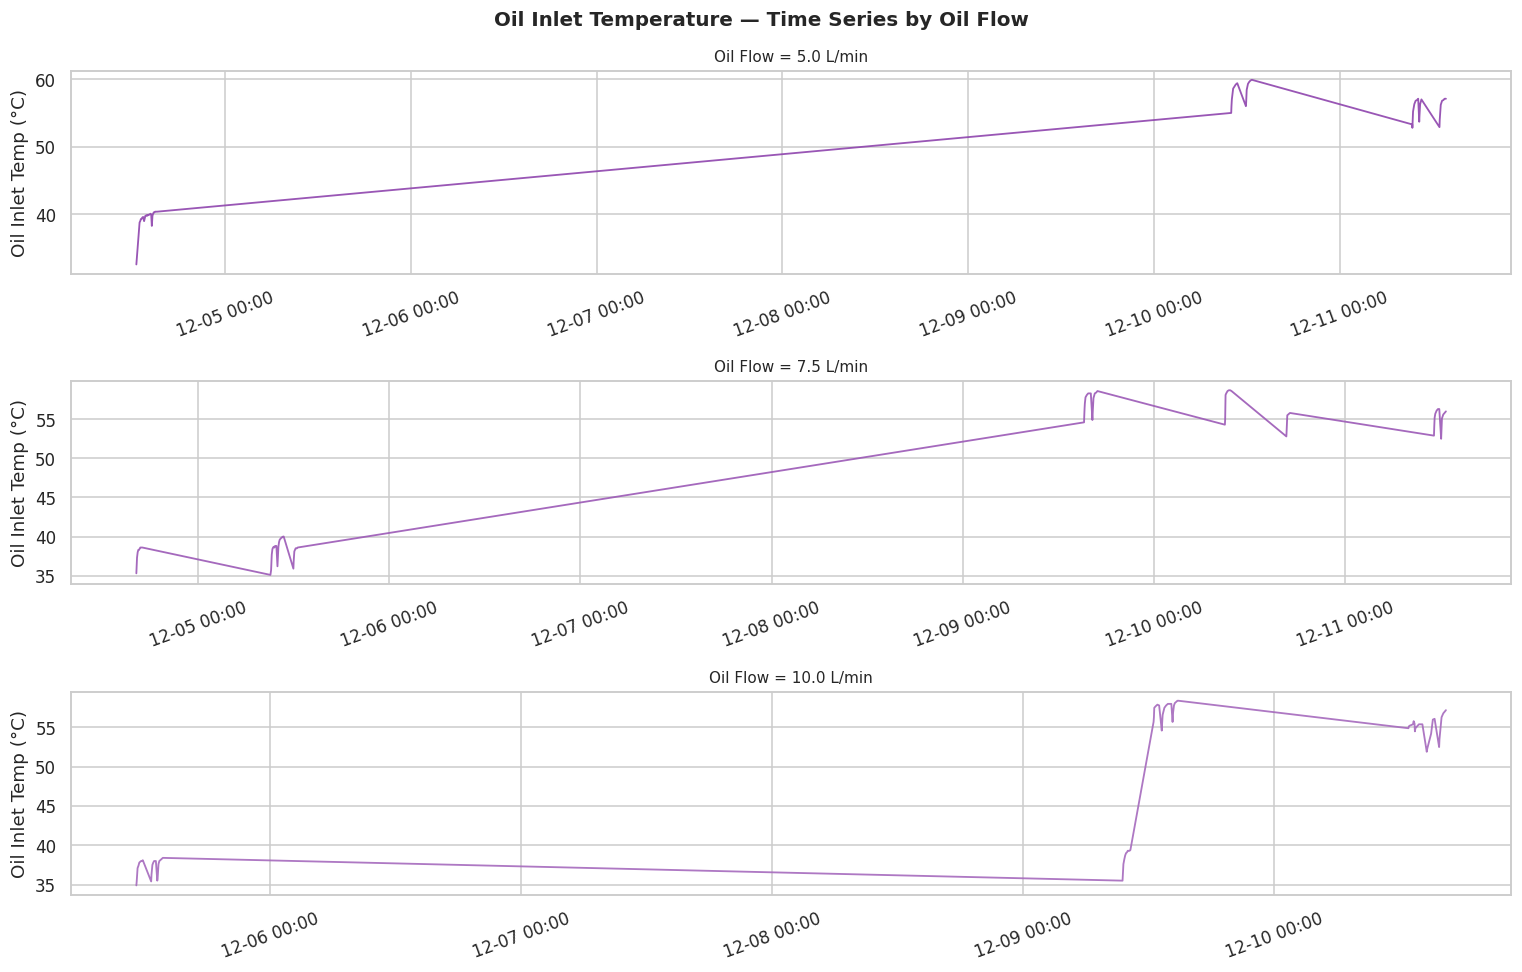

In [21]:
ts_by_flow('oil_temp_in', 'Oil Inlet Temp (°C)',
           'Oil Inlet Temperature — Time Series by Oil Flow',
           palette={5.0:'#8e44ad', 7.5:'#9b59b6', 10.0:'#a569bd'})

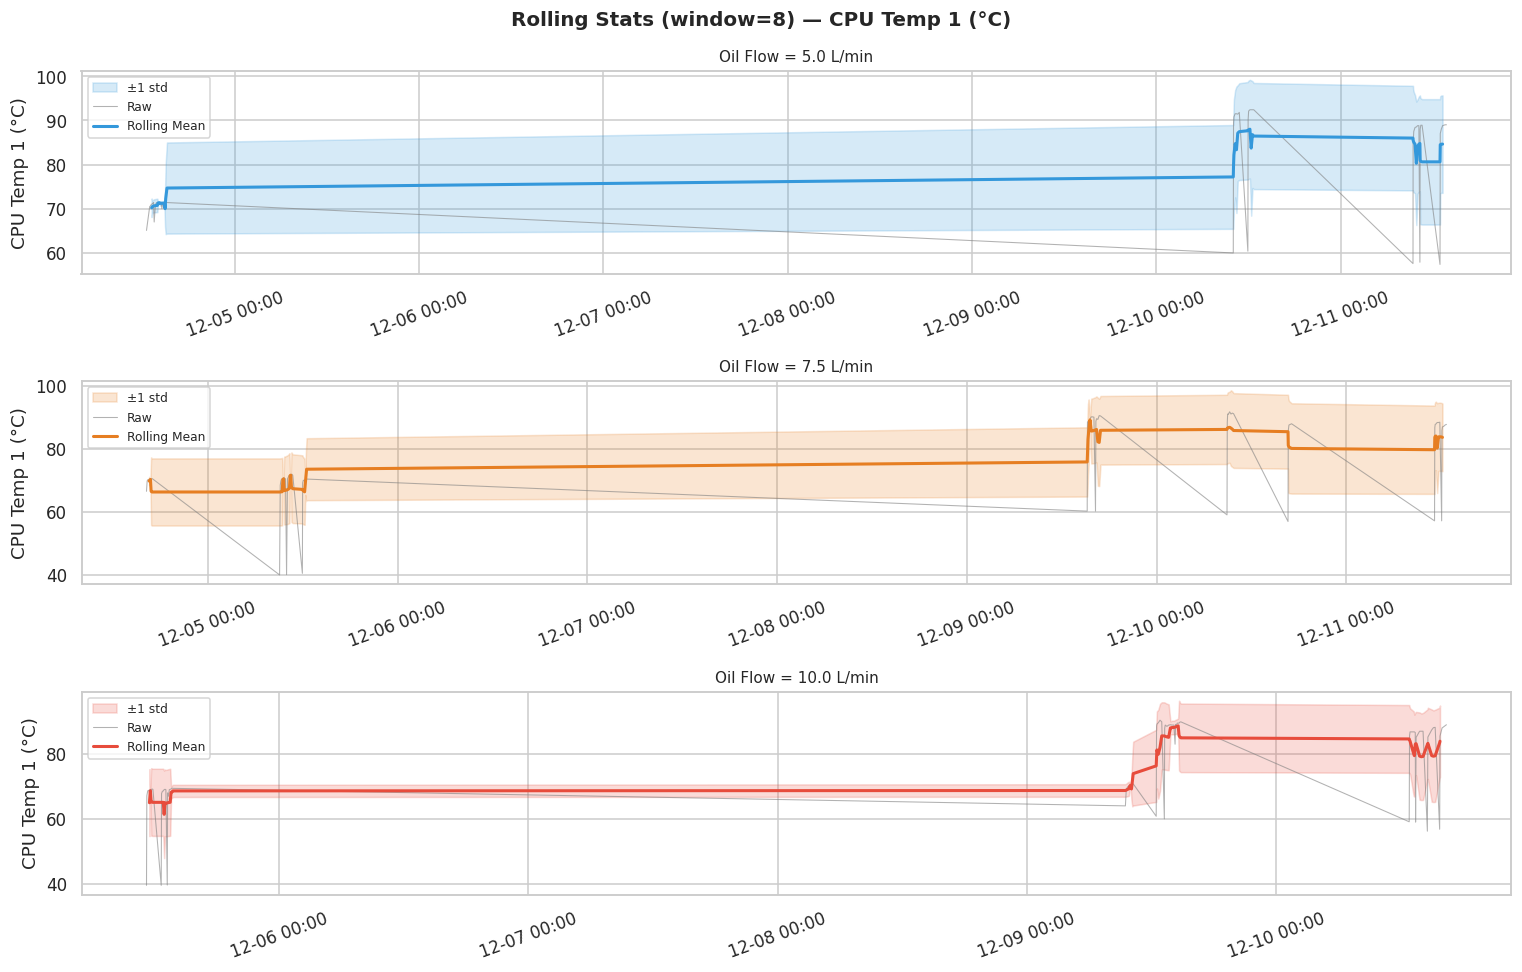

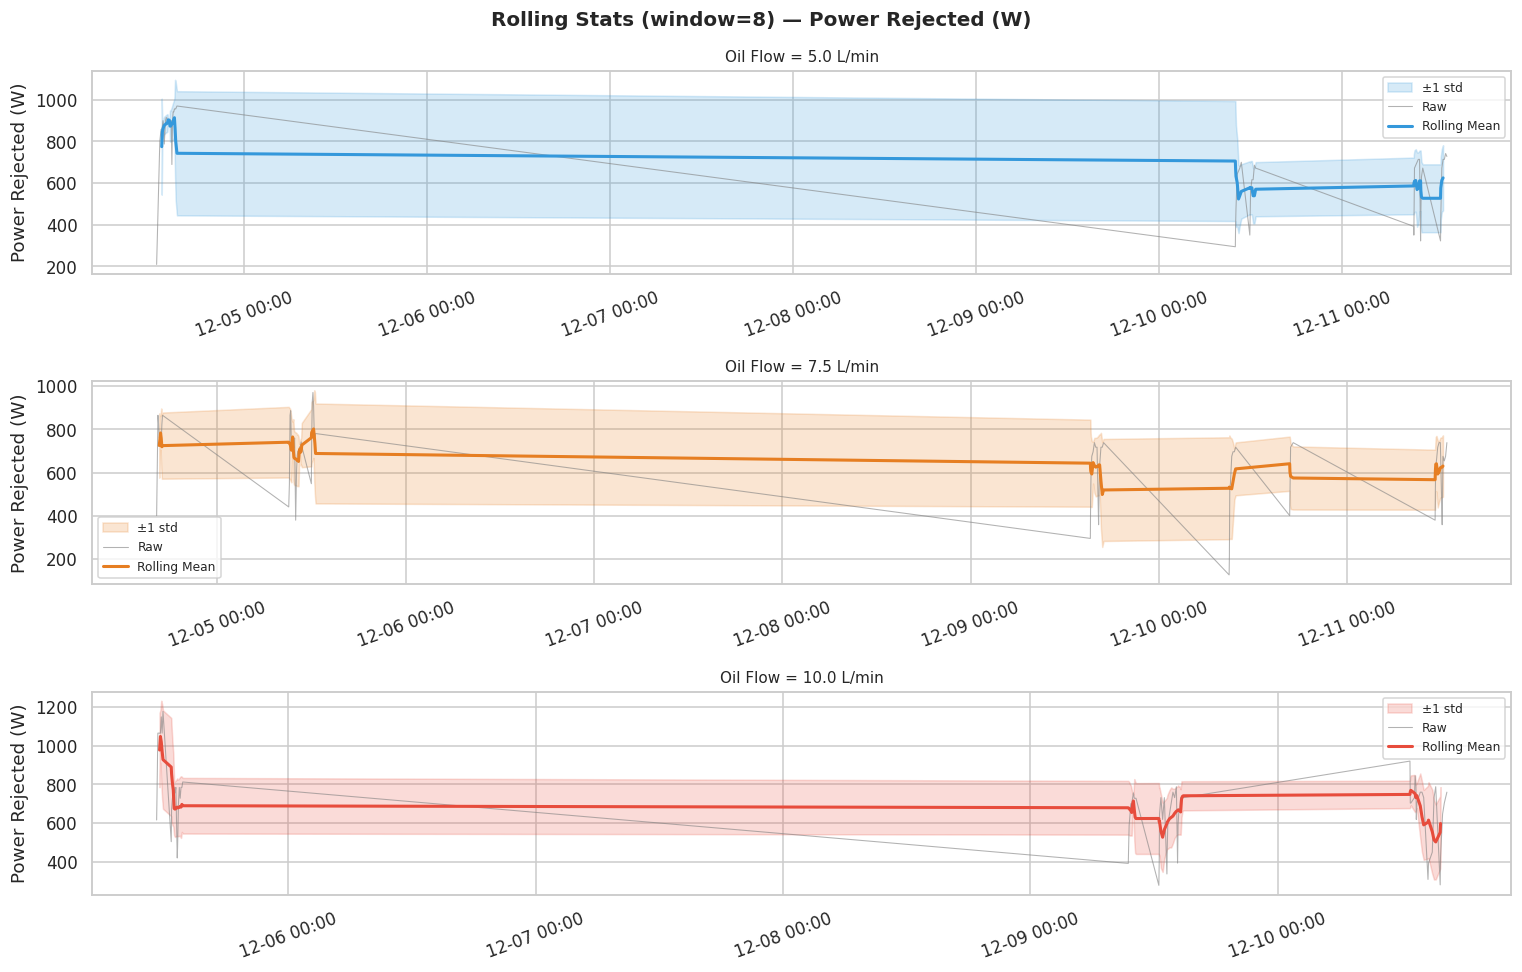

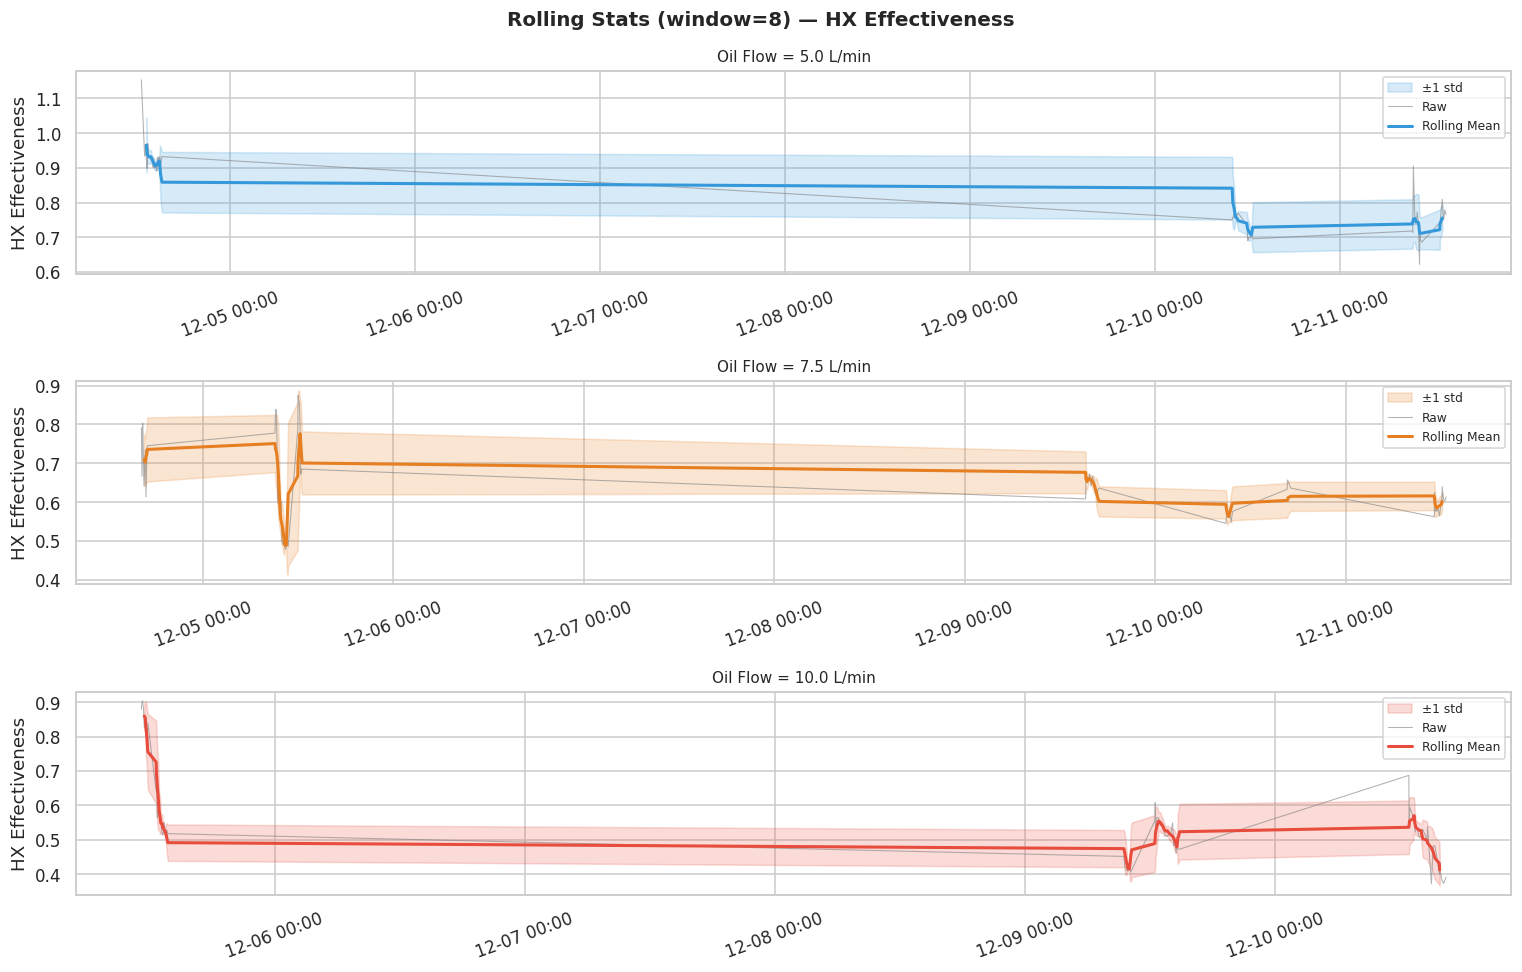

In [22]:
WINDOW = 8   # smaller window given 98 rows
flow_colors = {5.0: '#3498db', 7.5: '#e67e22', 10.0: '#e74c3c'}

for col, ylabel in [('cpu1_C', 'CPU Temp 1 (°C)'),
                     ('power_rejected_W', 'Power Rejected (W)'),
                     ('hx_eff', 'HX Effectiveness')]:

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
    fig.suptitle(f'Rolling Stats (window={WINDOW}) — {ylabel}',
                 fontsize=13, fontweight='bold')

    for ax, flow in zip(axes, [5.0, 7.5, 10.0]):
        sub = df[df.oil_flow == flow].set_index('Timestamp').sort_index()
        raw    = sub[col]
        rmean  = raw.rolling(WINDOW, center=True).mean()
        rstd   = raw.rolling(WINDOW, center=True).std()
        color  = flow_colors[flow]

        ax.fill_between(rmean.index, rmean - rstd, rmean + rstd,
                        alpha=0.2, color=color, label='±1 std')
        ax.plot(raw.index, raw.values, color='grey', lw=0.7, alpha=0.6, label='Raw')
        ax.plot(rmean.index, rmean.values, color=color, lw=2, label='Rolling Mean')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Oil Flow = {flow} L/min', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.tick_params(axis='x', rotation=20)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

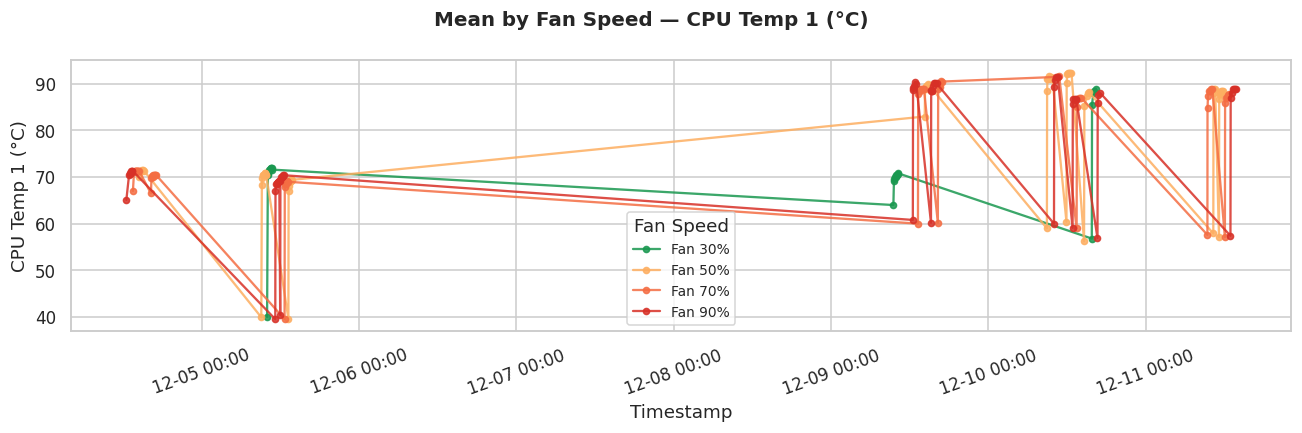

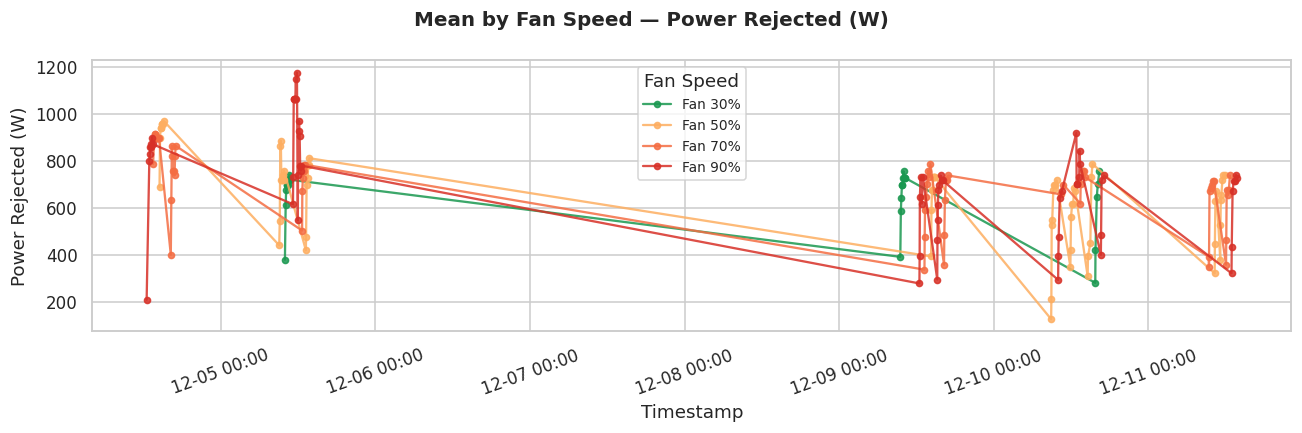

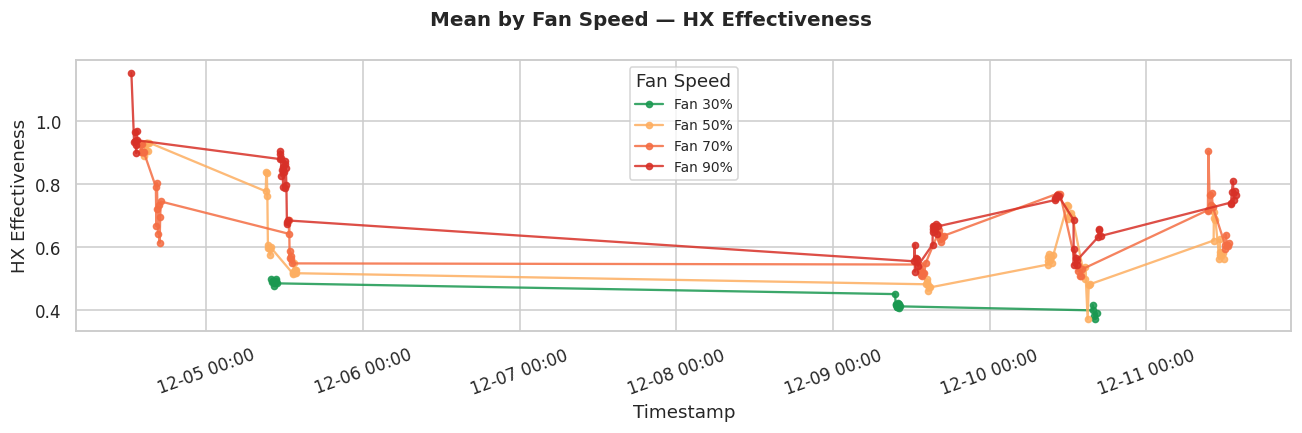

In [23]:
palette_fan_c = {30:'#1a9850', 50:'#fdae61', 70:'#f46d43', 90:'#d73027'}

for col, ylabel in [('cpu1_C',          'CPU Temp 1 (°C)'),
                     ('power_rejected_W', 'Power Rejected (W)'),
                     ('hx_eff',          'HX Effectiveness')]:

    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle(f'Mean by Fan Speed — {ylabel}', fontsize=13, fontweight='bold')

    for fan, color in palette_fan_c.items():
        sub = df[df.fan_pct == fan].set_index('Timestamp').sort_index()
        ax.plot(sub.index, sub[col], color=color, lw=1.5, alpha=0.85,
                marker='o', ms=4, label=f'Fan {fan}%')

    ax.set_ylabel(ylabel)
    ax.set_xlabel('Timestamp')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Fan Speed', fontsize=9)
    plt.tight_layout()
    plt.show()

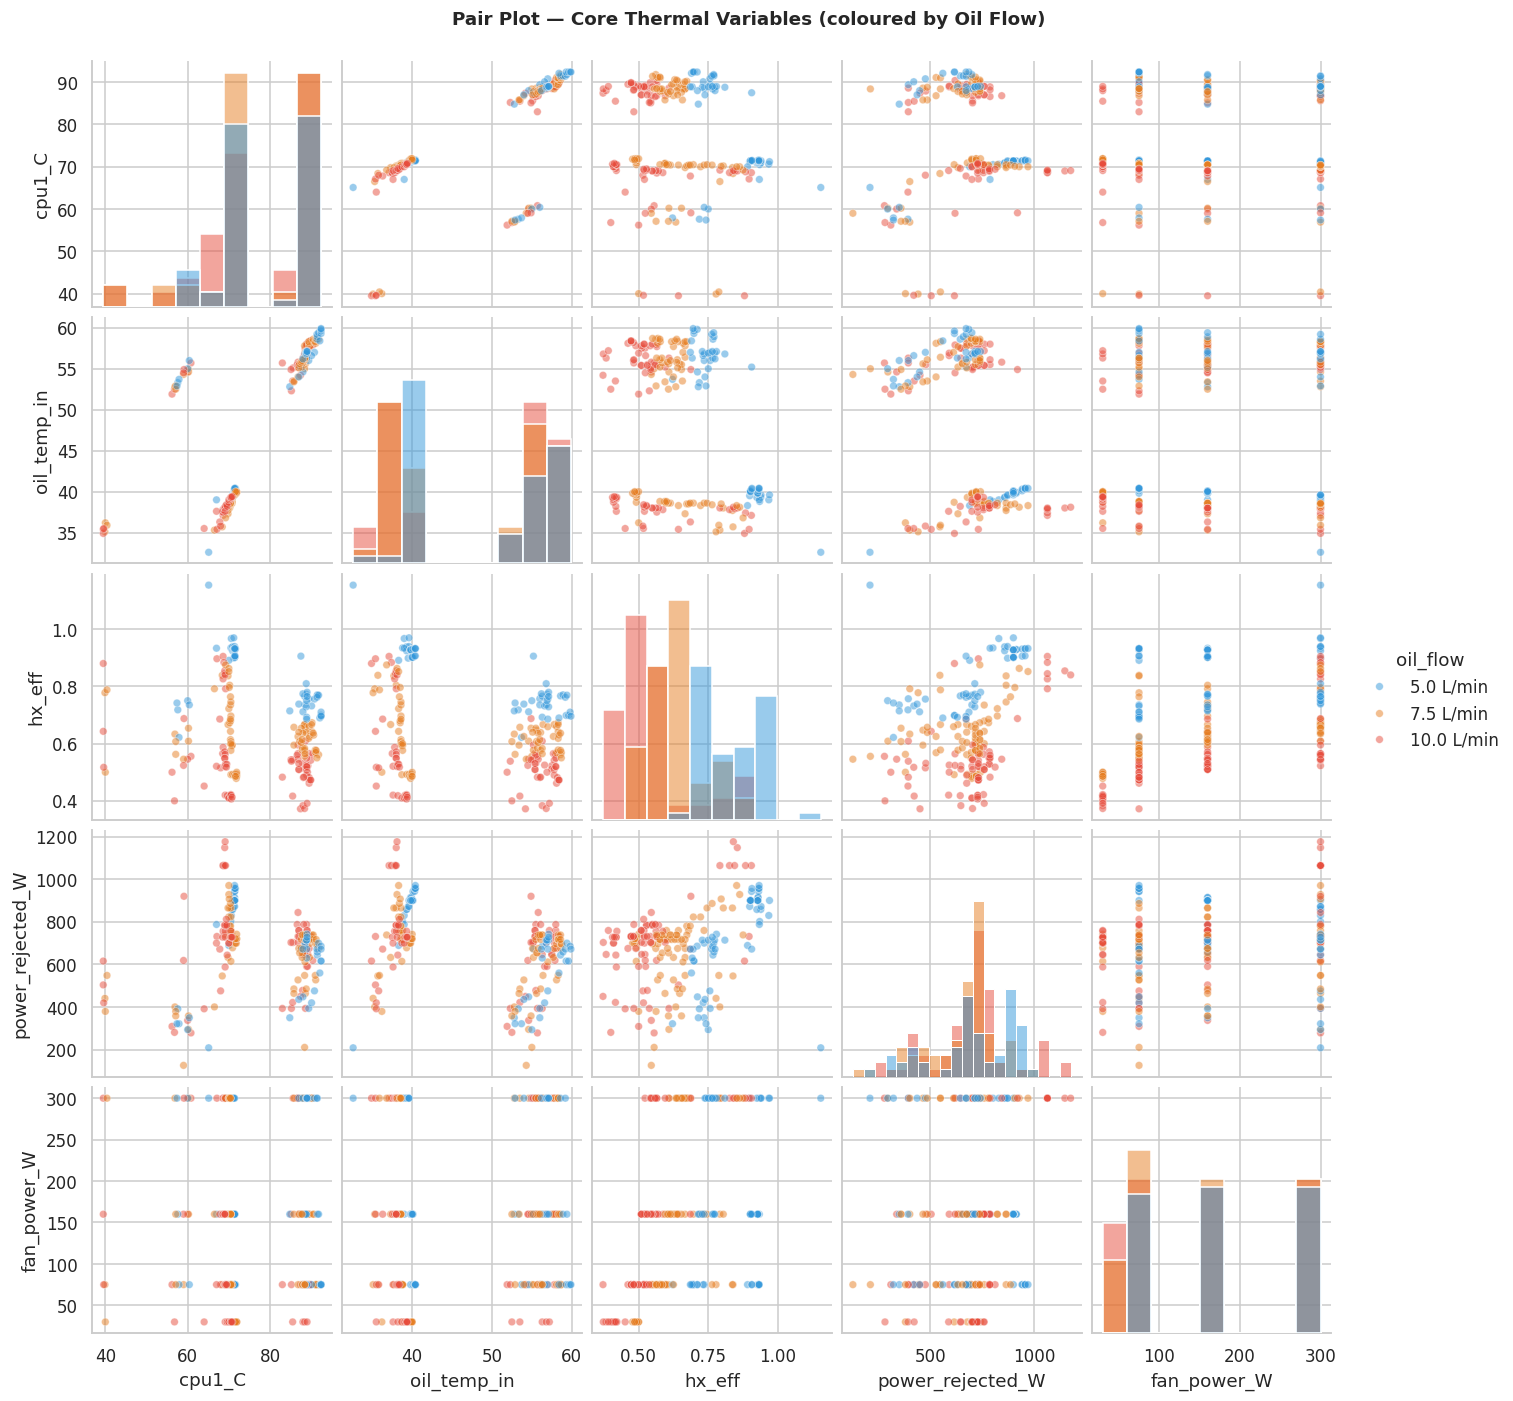

In [24]:
pair_cols = ['cpu1_C','oil_temp_in','hx_eff','power_rejected_W','fan_power_W']
pair_df = df[pair_cols + ['oil_flow']].copy()
pair_df['oil_flow'] = pair_df['oil_flow'].astype(str) + ' L/min'

g = sns.pairplot(pair_df, hue='oil_flow',
                 palette={'5.0 L/min':'#3498db','7.5 L/min':'#e67e22','10.0 L/min':'#e74c3c'},
                 plot_kws={'alpha':0.5, 's':25},
                 diag_kind='hist')
g.fig.suptitle('Pair Plot — Core Thermal Variables (coloured by Oil Flow)',
               y=1.02, fontsize=12, fontweight='bold')
plt.show()

In [26]:
# =========================
# ENGINEERED FEATURES
# =========================

# 1. CPU features
df['cpu_temp_avg'] = (df['cpu1_C'] + df['cpu2_C']) / 2
df['cpu_temp_diff'] = abs(df['cpu1_C'] - df['cpu2_C'])

# 2. Power feature
df['total_power_w'] = df['fan_power_W'] + df['pump_power_W'] + df['edge_power_W']

# 3. Interaction feature
df['fan_oil_interact'] = df['fan_pct'] * df['oil_flow']

# 4. Thermal ratios (add epsilon to avoid division by zero)
eps = 1e-6

df['thermal_ratio'] = (df['oil_temp_in'] - df['oil_temp_out']) / (
    (df['oil_temp_in'] - df['air_temp_in']) + eps
)

df['air_oil_delta_ratio'] = (df['air_temp_out'] - df['air_temp_in']) / (
    (df['oil_temp_out'] - df['oil_temp_in']) + eps
)

# 5. Heat capacity
df['oil_heat_capacity'] = df['oil_mass_gs'] * df['oil_cp']

# 6. Ambient delta
df['ambient_cpu_delta'] = df['cpu_temp_avg'] - df['ambient_C']

# 7. Non-linear terms
df['fan2'] = df['fan_pct'] ** 2
df['oil_flow2'] = df['oil_flow'] ** 2

# 8. LMTD (Log Mean Temperature Difference)
delta1 = df['oil_temp_in'] - df['air_temp_out']
delta2 = df['oil_temp_out'] - df['air_temp_in']

df['lmtd'] = (delta1 - delta2) / (np.log((delta1 + eps) / (delta2 + eps)) + eps)

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Feature matrix — exclude IDs, timestamps, raw derived targets
feature_cols = [
    # original features
    'ambient_C', 'oil_flow', 'fan_pct',
    'cpu1_C', 'cpu2_C',
    'oil_temp_in', 'oil_temp_out',
    'air_temp_in', 'air_temp_out',
    'fan_power_W', 'pump_power_W', 'edge_power_W',
    'oil_mass_gs', 'oil_density', 'oil_cp',
    'oil_delta_C', 'oil_avg_C',
    'air_delta_C', 'liq_delta_C', 'liq_max_dT',
    'liq_in_C', 'liq_out_C',

    # NEW engineered features
    'cpu_temp_avg',
    'cpu_temp_diff',
    'total_power_w',
    'fan_oil_interact',
    'thermal_ratio', # This is a direct calculation of hx_eff, so remove for hx_eff prediction
    'air_oil_delta_ratio',
    'oil_heat_capacity',
    'ambient_cpu_delta',
    'fan2',
    'oil_flow2',
    'lmtd'
]

X = df[feature_cols].copy()
y_hx  = df['hx_eff']
y_pwr = df['power_rejected_W']

# Exclude target from features when predicting that target
X_hx  = X.drop(columns=['thermal_ratio'], errors='ignore')   # hx_eff was leaked via 'thermal_ratio'
X_pwr = X.drop(columns=[], errors='ignore')   # power_rejected_W not in X

X_train_hx,  X_test_hx,  y_train_hx,  y_test_hx  = train_test_split(
    X_hx,  y_hx,  test_size=0.20, random_state=42)
X_train_pwr, X_test_pwr, y_train_pwr, y_test_pwr = train_test_split(
    X_pwr, y_pwr, test_size=0.20, random_state=42)

print(f'Train size: {len(X_train_hx)}, Test size: {len(X_test_hx)}')
print(f'Features for HX prediction: {X_hx.shape[1]}')
print(f'Features for Power prediction: {X_pwr.shape[1]}')

Train size: 170, Test size: 43
Features for HX prediction: 32
Features for Power prediction: 33


In [31]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def evaluate_models(X_tr, X_te, y_tr, y_te, target_name, selected_models=None):
    models = {
        'Linear Regression':     LinearRegression(),
        'Ridge':                 Ridge(alpha=1.0),
        'Lasso':                 Lasso(alpha=0.01),
        'ElasticNet':            ElasticNet(alpha=0.01, l1_ratio=0.5),
        'KNN (k=5)':             KNeighborsRegressor(n_neighbors=5),
        'Decision Tree':         DecisionTreeRegressor(max_depth=6, random_state=42),
        'Random Forest':         RandomForestRegressor(n_estimators=200, random_state=42),
        'Extra Trees':           ExtraTreesRegressor(n_estimators=200, random_state=42),
        'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, random_state=42),
        'XGBoost':               XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
        'LightGBM':              LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
        'SVR':                   SVR(kernel='rbf', C=100, epsilon=0.1),
        'MLP Neural Network':    MLPRegressor(hidden_layer_sizes=(64,32), max_iter=1000,
                                              random_state=42),
    }

    # Impute missing values first
    imputer = SimpleImputer(strategy='mean')
    X_tr_imputed = imputer.fit_transform(X_tr)
    X_te_imputed = imputer.transform(X_te)

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_imputed)
    X_te_sc = scaler.transform(X_te_imputed)

    results = []
    for name, model in models.items():
        if selected_models is None or name in selected_models:
            # Models that need scaling
            needs_scale = name in ['Linear Regression','Ridge','Lasso','ElasticNet',
                                    'KNN (k=5)','SVR','MLP Neural Network']

            # Use imputed data (already numpy arrays)
            Xtr = X_tr_sc if needs_scale else X_tr_imputed
            Xte = X_te_sc if needs_scale else X_te_imputed

            model.fit(Xtr, y_tr)
            pred = model.predict(Xte)
            mae  = mean_absolute_error(y_te, pred)
            rmse = np.sqrt(mean_squared_error(y_te, pred))
            r2   = r2_score(y_te, pred)
            results.append({'Model': name, 'MAE': round(mae,4),
                            'RMSE': round(rmse,4), 'R²': round(r2,4)})

    res_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
    print(f'\n{"="*55}')
    print(f'  TARGET: {target_name}')
    print(f'{"="*55}')
    print(res_df.to_string(index=False))
    return res_df


In [39]:
selected_models = ['Linear Regression', 'Ridge', 'ElasticNet', 'Random Forest', 'Extra Trees']

print('Evaluating models for HX Effectiveness:')
results_hx = evaluate_models(X_train_hx, X_test_hx, y_train_hx, y_test_hx,
                             'HX Effectiveness', selected_models=selected_models)

print('\nEvaluating models for Oil Power Rejected (W):')
results_pwr = evaluate_models(X_train_pwr, X_test_pwr, y_train_pwr, y_test_pwr,
                              'Oil Power Rejected (W)', selected_models=selected_models)

Evaluating models for HX Effectiveness:

  TARGET: HX Effectiveness
            Model    MAE   RMSE     R²
            Ridge 0.0165 0.0203 0.9830
Linear Regression 0.0167 0.0205 0.9827
       ElasticNet 0.0224 0.0288 0.9658
    Random Forest 0.0168 0.0307 0.9611
      Extra Trees 0.0169 0.0311 0.9601

Evaluating models for Oil Power Rejected (W):

  TARGET: Oil Power Rejected (W)
            Model     MAE    RMSE     R²
      Extra Trees 16.1077 25.3211 0.9795
       ElasticNet 19.6078 27.6658 0.9755
            Ridge 19.8274 27.7872 0.9753
Linear Regression 18.7850 28.4974 0.9740
    Random Forest 33.8809 51.0741 0.9166


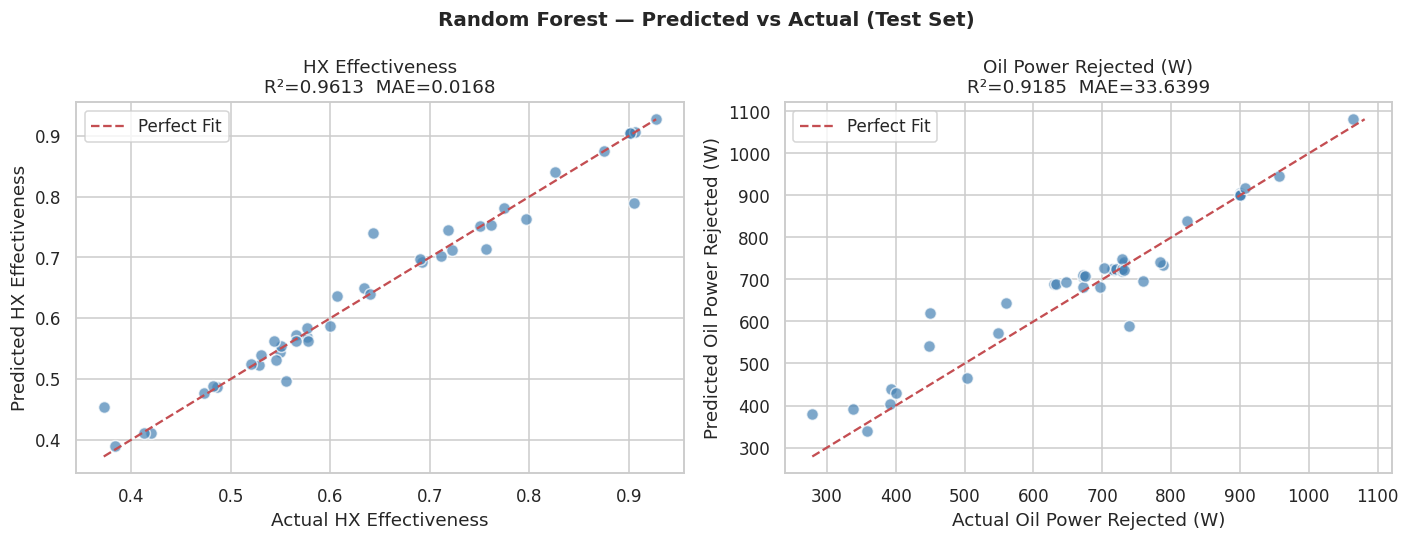

In [35]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

scaler = StandardScaler()
X_tr_sc_hx = scaler.fit_transform(X_train_hx)
X_te_sc_hx  = scaler.transform(X_test_hx)

# Retrain best models (Random Forest / XGBoost typically win on small datasets)
rf_hx = RandomForestRegressor(n_estimators=300, random_state=42)
rf_hx.fit(X_train_hx.values, y_train_hx)
pred_hx = rf_hx.predict(X_test_hx.values)

rf_pwr = RandomForestRegressor(n_estimators=300, random_state=42)
rf_pwr.fit(X_train_pwr.values, y_train_pwr)
pred_pwr = rf_pwr.predict(X_test_pwr.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest — Predicted vs Actual (Test Set)', fontsize=13, fontweight='bold')

for ax, y_true, y_pred, name in [
    (axes[0], y_test_hx,  pred_hx,  'HX Effectiveness'),
    (axes[1], y_test_pwr, pred_pwr, 'Oil Power Rejected (W)')
]:
    ax.scatter(y_true, y_pred, color='steelblue', alpha=0.7, edgecolors='white', s=60)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
    ax.set_xlabel(f'Actual {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}\nR²={r2_score(y_true, y_pred):.4f}  MAE={mean_absolute_error(y_true, y_pred):.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

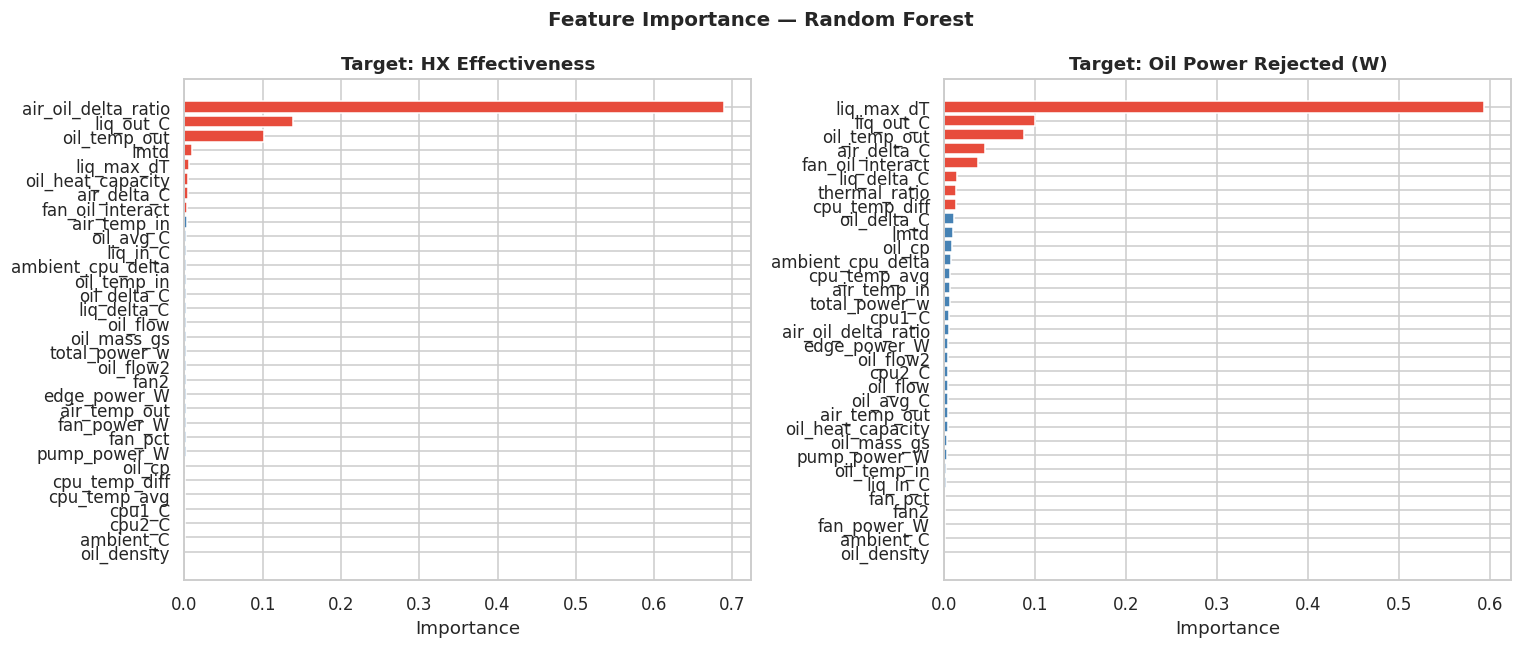

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance — Random Forest', fontsize=13, fontweight='bold')

for ax, model, name, X_train_data in [
    (axes[0], rf_hx, 'HX Effectiveness', X_train_hx),
    (axes[1], rf_pwr, 'Oil Power Rejected (W)', X_train_pwr)
]:
    # Use the columns of the X_train_data corresponding to the model
    imp = pd.Series(model.feature_importances_, index=X_train_data.columns).sort_values()
    colors_imp = ['#e74c3c' if v > imp.quantile(0.75) else 'steelblue' for v in imp]
    ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='white')
    ax.set_title(f'Target: {name}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [40]:
print('='*65)
print(' FINAL SUMMARY — AI EDGE PERFORMANCE DATASET')
print('='*65)

for res_df, target in [(results_hx, 'HX Effectiveness'),
                        (results_pwr, 'Oil Power Rejected (W)')]:
    best = res_df.iloc[0]
    print(f'\n  Target : {target}')
    print(f'  Best   : {best["Model"]}')
    print(f'  R²     : {best["R²"]:.4f}')
    print(f'  MAE    : {best["MAE"]:.4f}')
    print(f'  RMSE   : {best["RMSE"]:.4f}')

 FINAL SUMMARY — AI EDGE PERFORMANCE DATASET

  Target : HX Effectiveness
  Best   : Ridge
  R²     : 0.9830
  MAE    : 0.0165
  RMSE   : 0.0203

  Target : Oil Power Rejected (W)
  Best   : Extra Trees
  R²     : 0.9795
  MAE    : 16.1077
  RMSE   : 25.3211
